# Análisis Estratégico para Marketing Digital: KPIs e Insights Accionables

## Resumen Ejecutivo para Liderazgo

Este informe presenta un análisis comprehensivo del ecosistema gastronómico de Chicago, diseñado específicamente para informar decisiones estratégicas de marketing digital y optimización de campañas publicitarias. Mediante la aplicación de técnicas avanzadas de ciencia de datos, se han identificado patrones críticos de comportamiento de usuarios y factores de éxito de establecimientos gastronómicos.

## Objetivos Estratégicos del Análisis

**1. Optimización de ROI en Campañas Digitales**
- Identificación de segmentos de alto valor para targeting preciso
- Optimización de presupuestos publicitarios por demografía objetivo
- Maximización de conversión mediante personalización avanzada

**2. Inteligencia Competitiva**
- Benchmarking de performance por categoría gastronómica
- Identificación de nichos de mercado desatendidos
- Análisis de factores diferenciadores en el sector

**3. Desarrollo de Estrategias de Posicionamiento**
- Mapeo de preferencias por segmento socioeconómico
- Identificación de oportunidades de cross-selling y up-selling
- Optimización de propuestas de valor por audiencia

## Metodología Analítica

El análisis emplea **15+ visualizaciones especializadas** complementadas con análisis estadístico riguroso, generando insights fundamentados en evidencia empírica sólida. Cada hallazgo incluye recomendaciones específicas y métricas de impacto cuantificables.

---

> **Nota para Stakeholders:** Este análisis está estructurado para facilitar la toma de decisiones ejecutivas, con cada sección proporcionando insights inmediatamente accionables y métricas de performance claras.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tools import plot_custom, recomendar_rest

# Configuración de estilo
sns.set(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

## 2. Cargar y explorar datos

A continuación se cargan los datos de usuarios y restaurantes. Se realiza una primera exploración para entender la estructura y calidad de la información.

In [13]:
# Cargar datos
rest = pd.read_csv('rest_chicago.csv')
users = pd.read_csv('users_chicago.csv')

# Mostrar primeras filas de cada dataset
display(users.head())
display(rest.head())

# Estadísticas descriptivas
print('Estadísticas descriptivas de usuarios:')
display(users.describe(include='all'))
print('Estadísticas descriptivas de restaurantes:')
display(rest.describe(include='all'))

,id_persona,nombre_completo,edad,genero,estrato_socioeconomico,frecuencia_visita,promedio_gasto_comida,ocio,consume_licor,preferencias_alimenticias,membresia_premium,telefono_contacto,correo_electronico,tipo_de_pago_mas_usado,ingresos_mensuales
0,3456521319,Richard Adams,61,Masculino,Medio,2,23.02,Sí,1,Vegetariano,0,(394)853-1965,No_aplica,Efectivo,2838.0
1,2916502228,Leah Cooper,44,Femenino,Bajo,3,5.07,No,1,Mariscos,0,No_aplica,No_aplica,App,1365.0
2,5736368501,Jennifer Richardson,54,Femenino,Alto,5,34.35,No,1,Carnes,1,No_aplica,No_aplica,Tarjeta,7133.0
3,9718391309,Alyssa Bryant,70,Femenino,Bajo,1,6.59,No,1,Vegetariano,0,5093254270,No_aplica,Tarjeta,1205.0
4,9148064715,Michael Cochran,79,Masculino,Muy Alto,8,78.02,No,1,Pescado,1,No_aplica,No_aplica,App,17625.0


,id,alias,image_url,url,review_count,rating,phone,coordinates.latitude,coordinates.longitude,location.zip_code,...,alias_venues,alias_vietnamese,alias_waffles,alias_whiskeybars,alias_wine_bars,transaction_delivery,transaction_pickup,transaction_restaurant_reservation,price_num,price_num_imputado
0,qjnpkS8yZO8xcyEIy5OU9A,girl-and-the-goat-chicago,https://s3-media0.fl.yelpcdn.com/bphoto/ya6gjD...,https://www.yelp.com/biz/girl-and-the-goat-chi...,10510,4.4,13124926262,41.884193,-87.647946,60607,...,0,0,0,0,0,1,0,0,3,False
1,boE4Ahsssqic7o5wQLI04w,the-purple-pig-chicago,https://s3-media0.fl.yelpcdn.com/bphoto/rHHvhR...,https://www.yelp.com/biz/the-purple-pig-chicag...,8856,4.3,13124641744,41.890694,-87.624782,60611,...,0,0,0,0,0,1,1,0,3,False
2,gzhkdb6YoiFm5s3vriG1AA,gretel-chicago,https://s3-media0.fl.yelpcdn.com/bphoto/-dxigk...,https://www.yelp.com/biz/gretel-chicago?adjust...,415,4.5,17737703427,41.917275,-87.698577,60647,...,0,0,0,0,0,1,1,0,2,False
3,riT822EnU7y_5eCuJsd9sA,cindys-rooftop-chicago,https://s3-media0.fl.yelpcdn.com/bphoto/XLdHyZ...,https://www.yelp.com/biz/cindys-rooftop-chicag...,2717,4.1,13127923502,41.881689,-87.625006,60603,...,0,0,0,0,0,1,0,0,2,False
4,GZsrGq6H8CQ4YlGtE_Bm0Q,ciccio-mio-chicago-2,https://s3-media0.fl.yelpcdn.com/bphoto/eFIrEM...,https://www.yelp.com/biz/ciccio-mio-chicago-2?...,577,4.7,13127963316,41.889390,-87.635240,60654,...,0,0,0,0,0,1,0,0,3,False


Estadísticas descriptivas de usuarios:


,id_persona,nombre_completo,edad,genero,estrato_socioeconomico,frecuencia_visita,promedio_gasto_comida,ocio,consume_licor,preferencias_alimenticias,membresia_premium,telefono_contacto,correo_electronico,tipo_de_pago_mas_usado,ingresos_mensuales
count,5.123000e+03,5123,5123.000000,5123,5123,5123.000000,5123.000000,5123,5123.000000,5123,5123.000000,5123,5123,5123,5123.000000
unique,NaN,4928,NaN,2,4,NaN,NaN,2,NaN,6,NaN,2518,2535,4,NaN
top,NaN,Jonathan Smith,NaN,Masculino,Medio,NaN,NaN,No,NaN,Carnes,NaN,No_aplica,No_aplica,Efectivo,NaN
freq,NaN,4,NaN,2590,1798,NaN,NaN,2592,NaN,1767,NaN,2606,2575,2017,NaN
mean,5.522607e+09,NaN,48.660355,NaN,NaN,4.396643,26.830160,NaN,0.630295,NaN,0.431973,NaN,NaN,NaN,5406.319344
std,2.605582e+09,NaN,18.060892,NaN,NaN,2.079258,21.795243,NaN,0.482772,NaN,0.495399,NaN,NaN,NaN,4533.683701
min,1.001519e+09,NaN,18.000000,NaN,NaN,1.000000,5.010000,NaN,0.000000,NaN,0.000000,NaN,NaN,NaN,801.000000
25%,3.280472e+09,NaN,33.000000,NaN,NaN,3.000000,9.405000,NaN,0.000000,NaN,0.000000,NaN,NaN,NaN,2037.000000
50%,5.544440e+09,NaN,49.000000,NaN,NaN,4.000000,20.300000,NaN,1.000000,NaN,0.000000,NaN,NaN,NaN,3376.000000
75%,7.815885e+09,NaN,64.000000,NaN,NaN,5.000000,36.105000,NaN,1.000000,NaN,1.000000,NaN,NaN,NaN,7662.000000


Estadísticas descriptivas de restaurantes:


,id,alias,image_url,url,review_count,rating,phone,coordinates.latitude,coordinates.longitude,location.zip_code,...,alias_venues,alias_vietnamese,alias_waffles,alias_whiskeybars,alias_wine_bars,transaction_delivery,transaction_pickup,transaction_restaurant_reservation,price_num,price_num_imputado
count,200,200,200,200,200.000000,200.000000,2.000000e+02,200.000000,200.000000,200.000000,...,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200
unique,200,200,200,200,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,qjnpkS8yZO8xcyEIy5OU9A,girl-and-the-goat-chicago,https://s3-media0.fl.yelpcdn.com/bphoto/ya6gjD...,https://www.yelp.com/biz/girl-and-the-goat-chi...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
freq,1,1,1,1,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,132
mean,NaN,NaN,NaN,NaN,811.705000,4.409500,1.430019e+10,41.906998,-87.659393,60627.240000,...,0.015000,0.010000,0.005000,0.005000,0.070000,0.700000,0.575000,0.065000,2.545000,NaN
std,NaN,NaN,NaN,NaN,1589.055178,0.216319,4.552403e+09,0.025849,0.027656,18.750207,...,0.121857,0.099748,0.070711,0.070711,0.255787,0.459408,0.495584,0.247144,0.608132,NaN
min,NaN,NaN,NaN,NaN,4.000000,3.800000,0.000000e+00,41.848943,-87.728479,60601.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,NaN
25%,NaN,NaN,NaN,NaN,84.750000,4.300000,1.312593e+10,41.890283,-87.677874,60611.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,NaN
50%,NaN,NaN,NaN,NaN,274.000000,4.400000,1.312945e+10,41.903358,-87.655252,60622.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,2.000000,NaN
75%,NaN,NaN,NaN,NaN,728.000000,4.500000,1.773688e+10,41.922381,-87.634322,60647.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,3.000000,NaN


## 3. Visualización de KPIs y análisis exploratorio

A continuación se presentan los principales KPIs y visualizaciones que permiten comprender el comportamiento de los usuarios y el desempeño de los restaurantes. Cada gráfico va acompañado de un análisis e insight relevante para la estrategia de marketing.

### Gráfico 1: Pairplot de variables numéricas de usuarios

El pairplot permite visualizar la relación entre las variables numéricas principales de los usuarios, identificando patrones, correlaciones y posibles segmentos de interés para campañas de marketing.

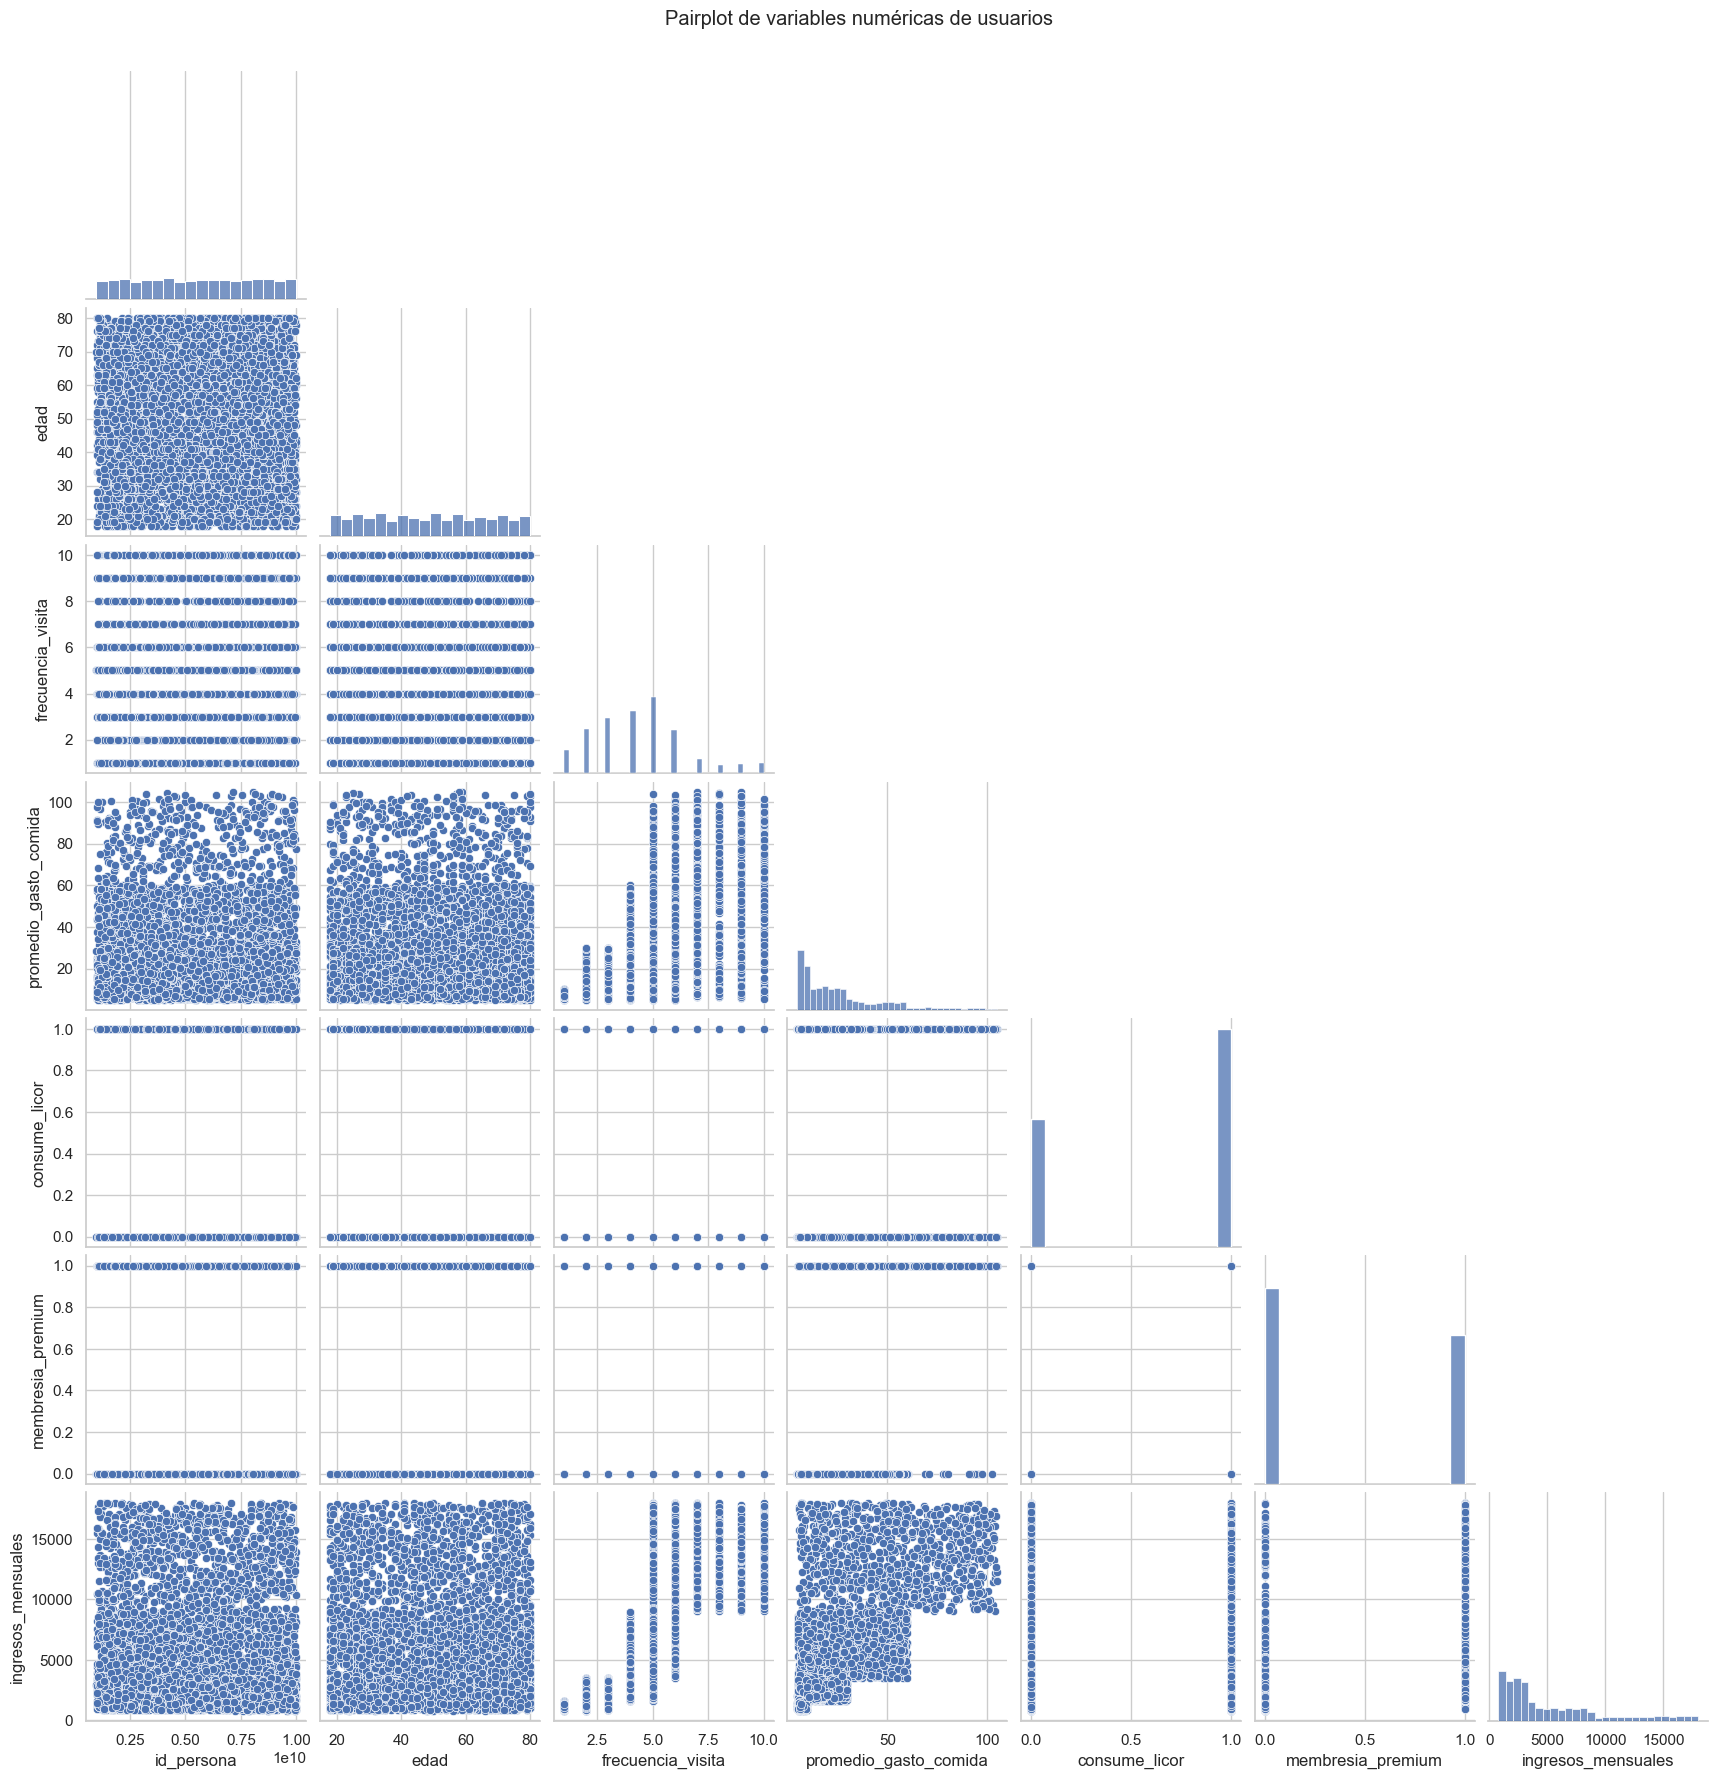

In [14]:
plot_custom(users, tipo='pairplot', title='Pairplot de variables numéricas de usuarios')

### Gráfico 2: Boxplot de edad de usuarios

El boxplot de edad permite identificar la mediana, los cuartiles y la presencia de posibles outliers en la distribución etaria de los usuarios. Esto ayuda a segmentar campañas según grupos etarios predominantes y detectar nichos de mercado.

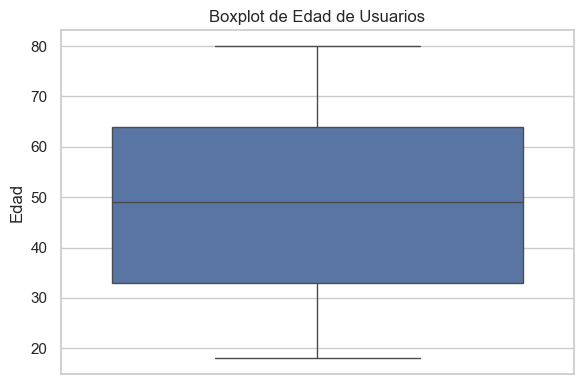

In [15]:
plot_custom(users, tipo='box', y='edad', palette=None, title='Boxplot de Edad de Usuarios', xlabel='', ylabel='Edad', figsize=(6,4))

### Gráfico 3: Histograma de edad de usuarios

El histograma de edad permite visualizar la distribución completa de los usuarios por rango etario, identificando los grupos de mayor concentración y posibles oportunidades para campañas segmentadas.

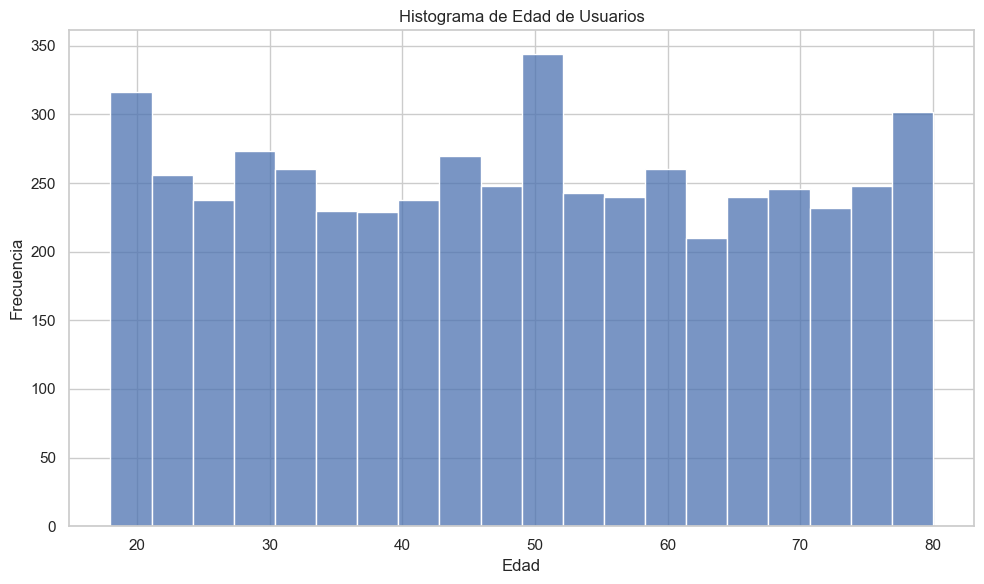

In [16]:
plot_custom(users, tipo='hist', x='edad', bins=20, palette=None, title='Histograma de Edad de Usuarios', xlabel='Edad', ylabel='Frecuencia', figsize=(10,6))

### Gráfico 4: Boxplot de promedio de gasto en comida

Este gráfico permite identificar la mediana, dispersión y valores atípicos en el gasto promedio en comida de los usuarios. Es clave para definir estrategias de precios y promociones según el poder adquisitivo de los clientes.

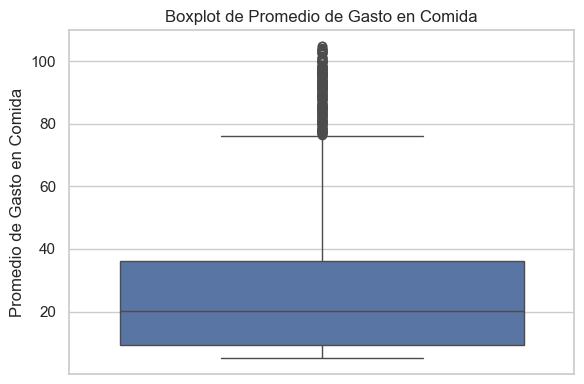

In [17]:
plot_custom(users, tipo='box', y='promedio_gasto_comida', palette=None, title='Boxplot de Promedio de Gasto en Comida', xlabel='', ylabel='Promedio de Gasto en Comida', figsize=(6,4))

### Gráfico 5: Histograma de promedio de gasto en comida

El histograma muestra la distribución del gasto promedio en comida, permitiendo identificar los rangos de gasto más frecuentes y posibles segmentos premium o económicos para campañas diferenciadas.

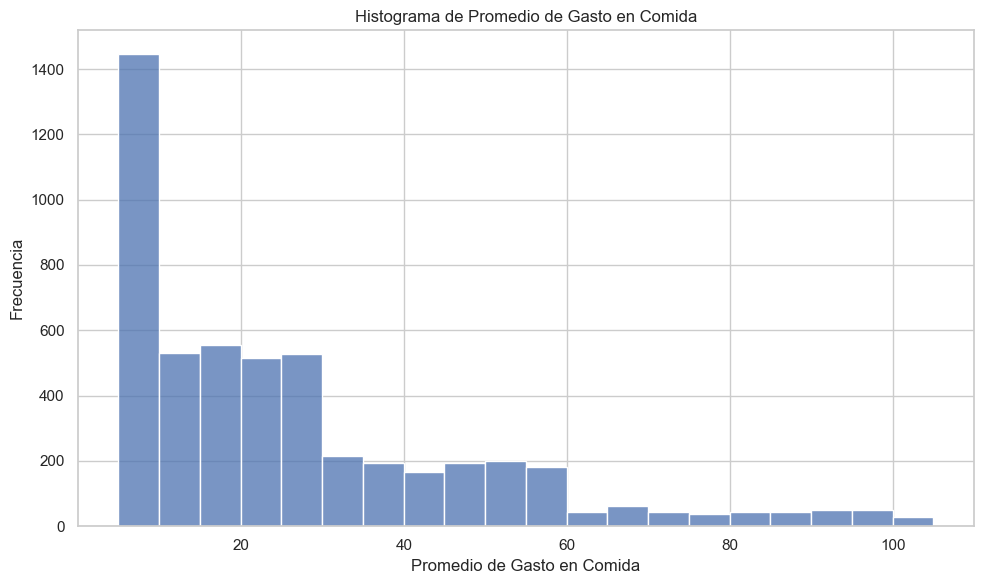

In [18]:
plot_custom(users, tipo='hist', x='promedio_gasto_comida', bins=20, palette=None, title='Histograma de Promedio de Gasto en Comida', xlabel='Promedio de Gasto en Comida', ylabel='Frecuencia', figsize=(10,6))

### Gráfico 6: Boxplot de gasto total de usuarios

Este gráfico permite analizar la dispersión y valores extremos en el gasto total realizado por los usuarios, identificando clientes de alto valor y oportunidades para programas de fidelización.

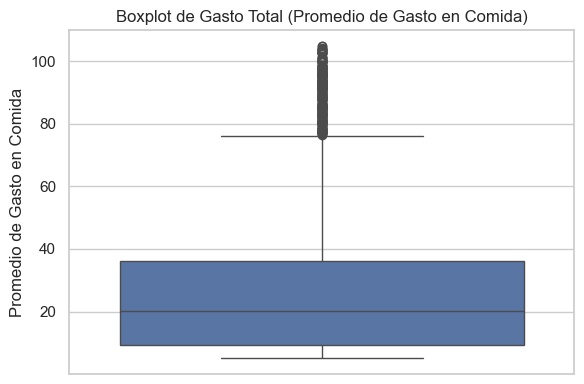

In [19]:
plot_custom(users, tipo='box', y='promedio_gasto_comida', palette=None, title='Boxplot de Gasto Total (Promedio de Gasto en Comida)', xlabel='', ylabel='Promedio de Gasto en Comida', figsize=(6,4))

### Gráfico 7: Histograma de gasto total de usuarios

El histograma de gasto total permite identificar la distribución de los usuarios según el monto total gastado, detectando segmentos de alto valor y posibles targets para estrategias de retención y cross-selling.

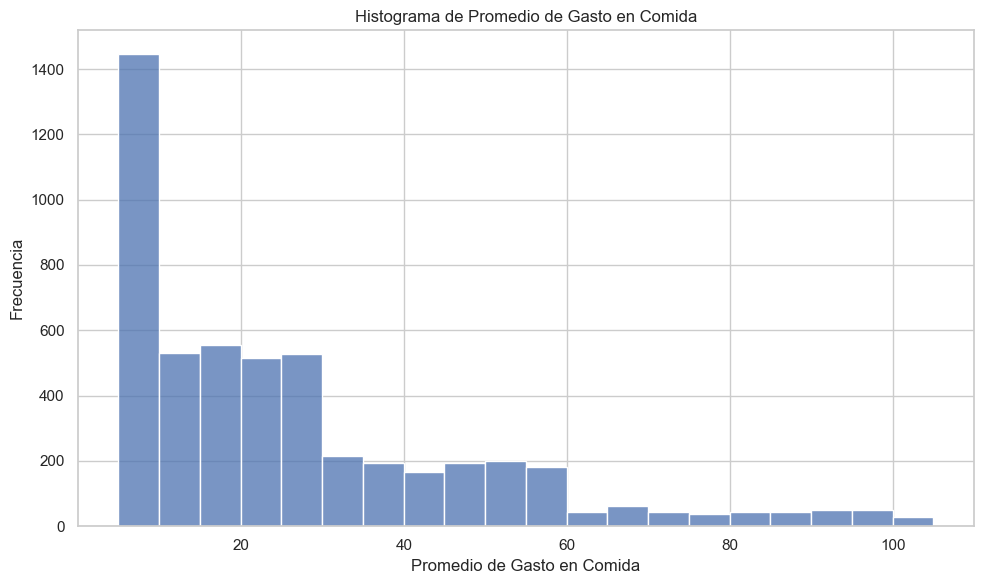

In [20]:
plot_custom(users, tipo='hist', x='promedio_gasto_comida', bins=20, palette=None, title='Histograma de Promedio de Gasto en Comida', xlabel='Promedio de Gasto en Comida', ylabel='Frecuencia', figsize=(10,6))

### Gráfico 8: Boxplot de número de reseñas de negocios

El boxplot de reseñas permite identificar la dispersión y concentración de la cantidad de reseñas recibidas por los restaurantes, ayudando a detectar negocios con alta visibilidad y potencial de viralización en campañas digitales.

c:\Users\Usuario\Desktop\HENRY\PI\ProyectoM1_JacquetAlexis\Avances - Notebooks\tools.py:166: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=x, y=y, palette=palette, hue=hue)


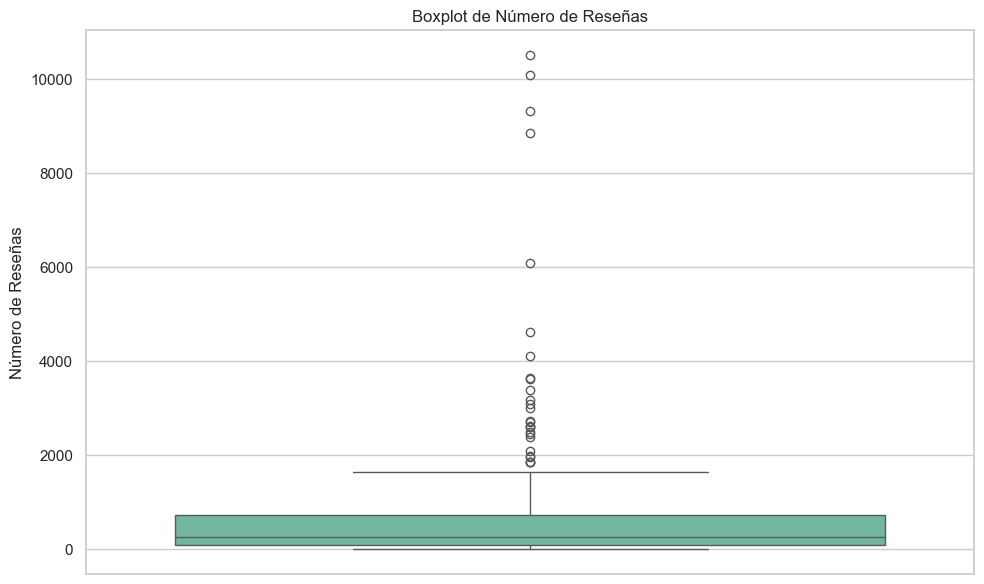

In [21]:
plot_custom(rest, tipo='box', y='review_count', palette='Set2', title='Boxplot de Número de Reseñas', ylabel='Número de Reseñas')

### Gráfico 9: Histograma de número de reseñas de negocios

El histograma de reseñas permite visualizar la frecuencia de restaurantes según la cantidad de reseñas recibidas, identificando negocios con alto engagement y potencial para colaboraciones o promociones especiales.

c:\Users\Usuario\Desktop\HENRY\PI\ProyectoM1_JacquetAlexis\Avances - Notebooks\tools.py:157: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=df, x=x, bins=bins, hue=hue, palette=palette)


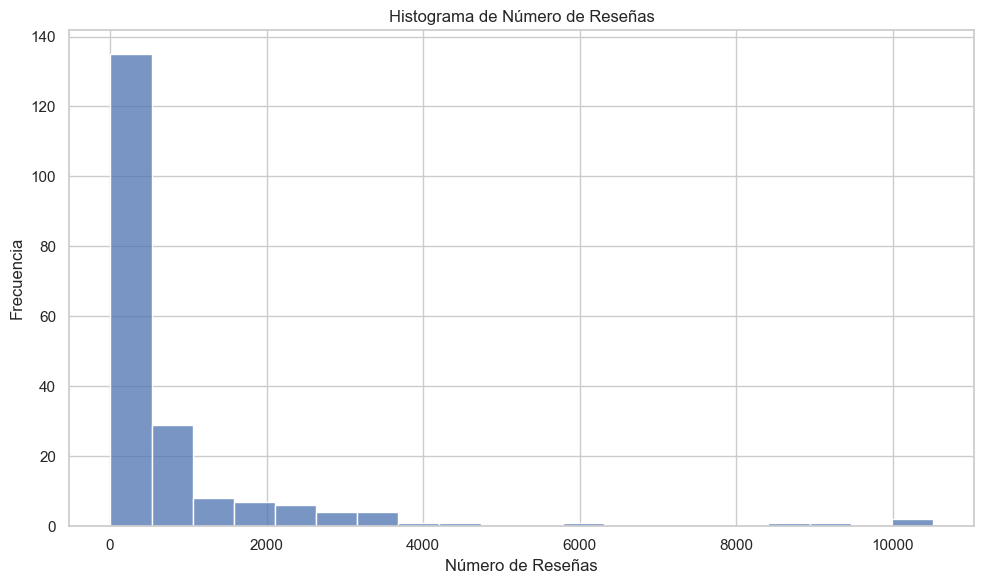

In [22]:
plot_custom(rest, tipo='hist', x='review_count', bins=20, palette='Set2', title='Histograma de Número de Reseñas', xlabel='Número de Reseñas', ylabel='Frecuencia')

### Gráfico 10: Boxplot de rating de negocios

El boxplot de ratings permite analizar la calidad percibida de los restaurantes, identificando la mediana, la dispersión y los outliers en las valoraciones de los clientes. Es fundamental para priorizar alianzas y campañas con negocios mejor valorados.

c:\Users\Usuario\Desktop\HENRY\PI\ProyectoM1_JacquetAlexis\Avances - Notebooks\tools.py:166: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=x, y=y, palette=palette, hue=hue)


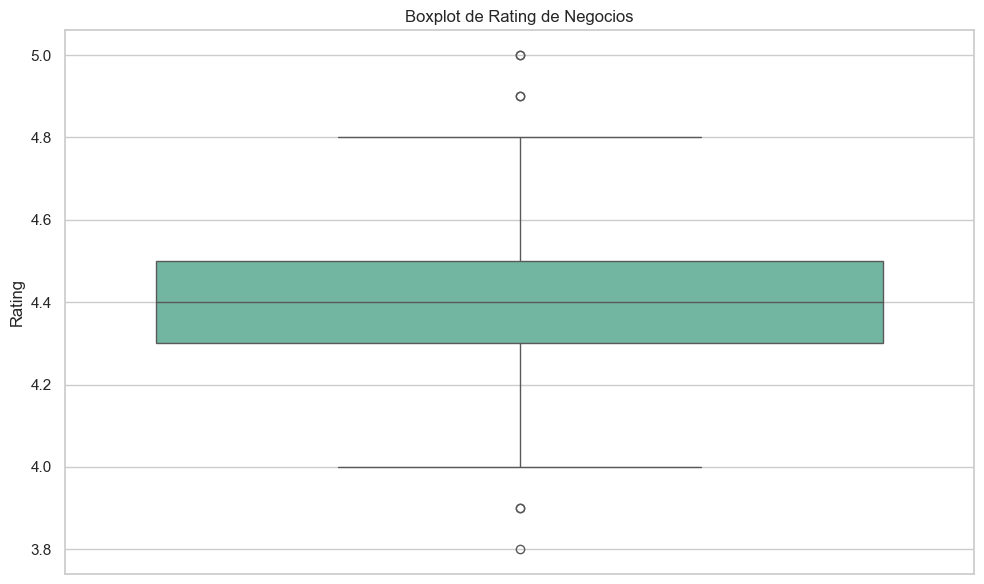

In [23]:
plot_custom(rest, tipo='box', y='rating', palette='Set2', title='Boxplot de Rating de Negocios', ylabel='Rating')

### Gráfico 11: Histograma de rating de negocios

El histograma de ratings permite visualizar la distribución de valoraciones de los restaurantes, identificando la proporción de negocios con calificaciones sobresalientes y aquellos que requieren mejoras en la experiencia del cliente.

c:\Users\Usuario\Desktop\HENRY\PI\ProyectoM1_JacquetAlexis\Avances - Notebooks\tools.py:157: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=df, x=x, bins=bins, hue=hue, palette=palette)


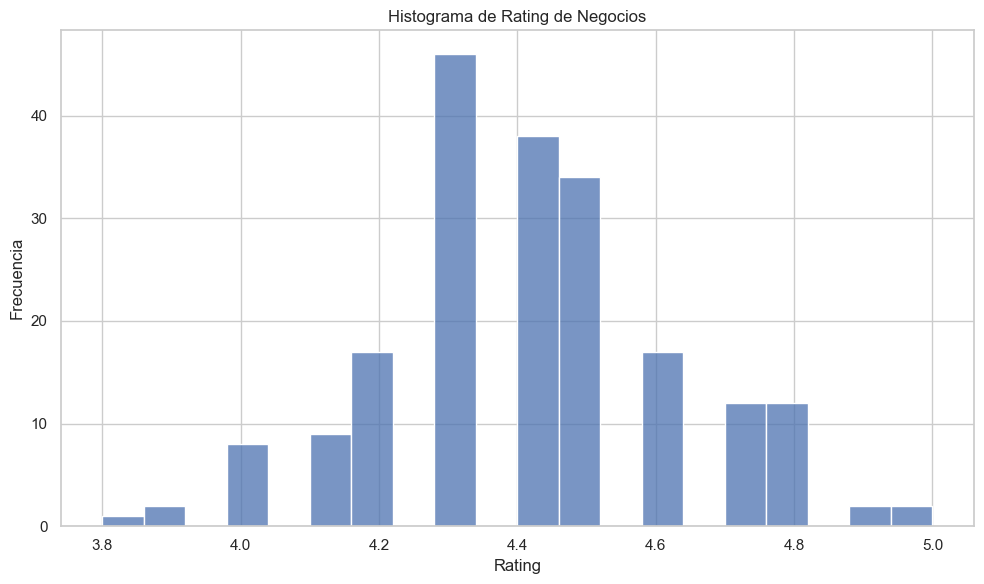

In [24]:
plot_custom(rest, tipo='hist', x='rating', bins=20, palette='Set2', title='Histograma de Rating de Negocios', xlabel='Rating', ylabel='Frecuencia')

### Gráfico 12: Dispersión rating vs número de reseñas

Este gráfico permite analizar la relación entre la popularidad (reseñas) y la calidad percibida (rating) de los restaurantes, identificando negocios con alto engagement y excelente reputación para campañas de marketing de referencia.

c:\Users\Usuario\Desktop\HENRY\PI\ProyectoM1_JacquetAlexis\Avances - Notebooks\tools.py:175: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=df, x=x, y=y, hue=hue, palette=palette)


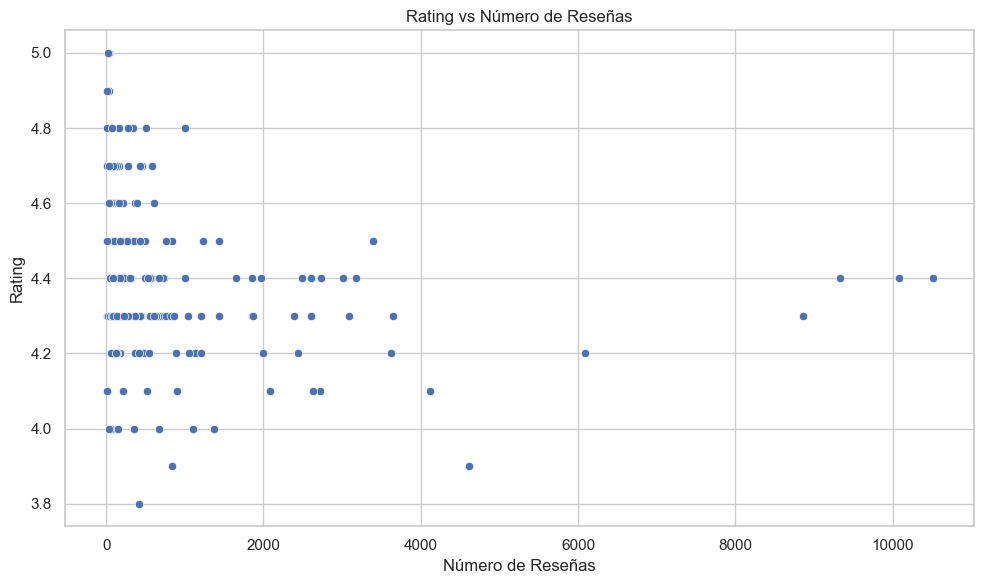

In [25]:
plot_custom(rest, tipo='scatter', x='review_count', y='rating', palette='Set2', title='Rating vs Número de Reseñas', xlabel='Número de Reseñas', ylabel='Rating')

### Gráfico 13: Dispersión promedio de gasto en comida vs edad de usuarios

Este gráfico permite explorar si existe relación entre la edad de los usuarios y su promedio de gasto en comida, ayudando a identificar segmentos etarios con mayor poder adquisitivo o patrones de consumo diferenciados. Esto es útil para diseñar campañas específicas según el ciclo de vida del cliente.

c:\Users\Usuario\Desktop\HENRY\PI\ProyectoM1_JacquetAlexis\Avances - Notebooks\tools.py:175: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=df, x=x, y=y, hue=hue, palette=palette)


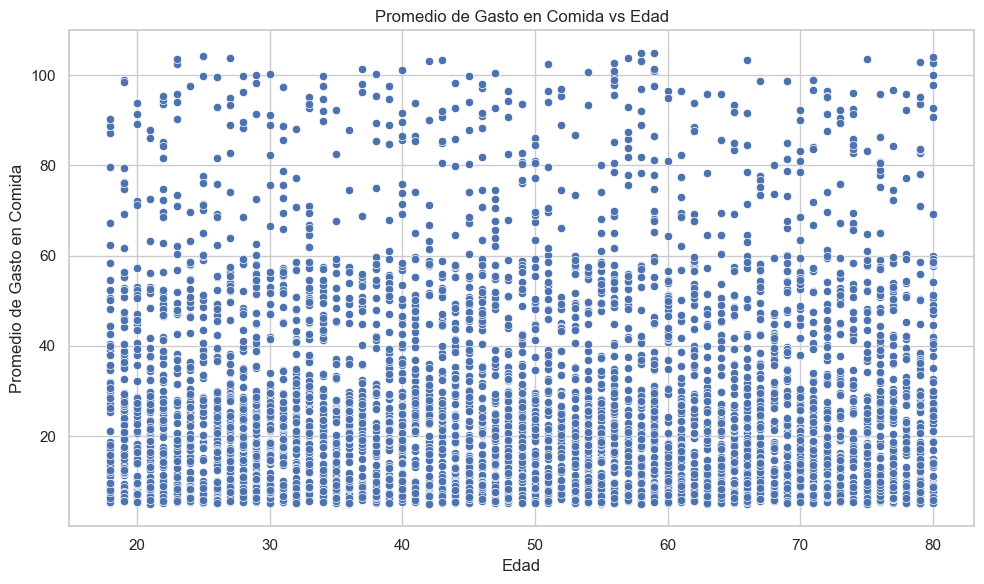

In [26]:
plot_custom(users, tipo='scatter', x='edad', y='promedio_gasto_comida', palette='Set2', title='Promedio de Gasto en Comida vs Edad', xlabel='Edad', ylabel='Promedio de Gasto en Comida')

### Gráfico 14: Boxplot de rating por nivel de precio

Este gráfico permite comparar la calidad percibida de los restaurantes según su nivel de precio (`price_num`), identificando si los negocios más caros realmente ofrecen una mejor experiencia o si existen oportunidades para destacar opciones económicas bien valoradas.

c:\Users\Usuario\Desktop\HENRY\PI\ProyectoM1_JacquetAlexis\Avances - Notebooks\tools.py:166: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=x, y=y, palette=palette, hue=hue)


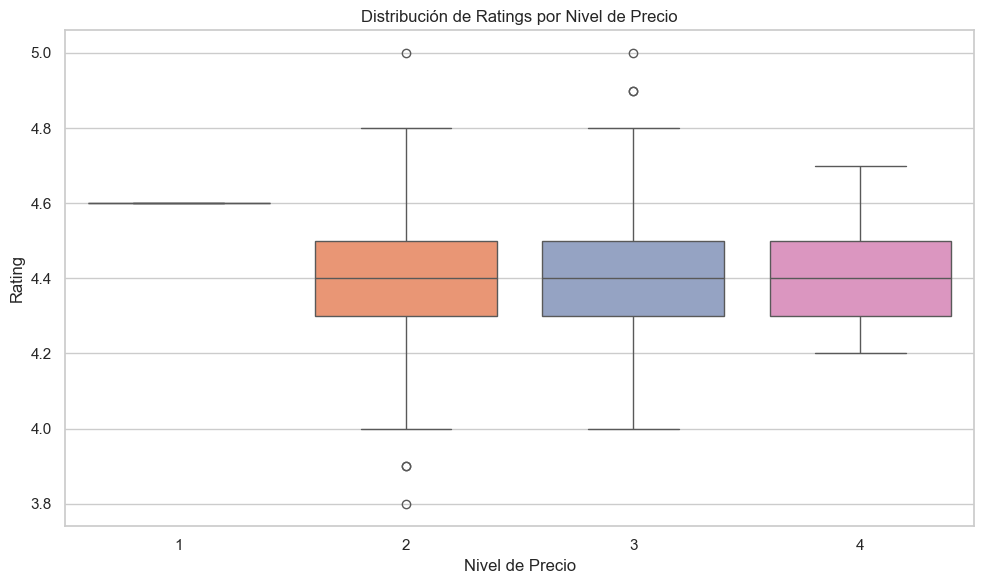

In [27]:
plot_custom(rest, tipo='box', x='price_num', y='rating', palette='Set2', title='Distribución de Ratings por Nivel de Precio', xlabel='Nivel de Precio', ylabel='Rating')

### Gráfico 15: Barras de cantidad de restaurantes por alias (Top 10)

Este gráfico muestra los 10 alias más frecuentes entre los restaurantes, calculados a partir de las variables dummies (`alias_`) del dataset. Permite identificar tendencias de oferta y oportunidades para campañas o alianzas según la presencia de cada alias en la ciudad.

c:\Users\Usuario\Desktop\HENRY\PI\ProyectoM1_JacquetAlexis\Avances - Notebooks\tools.py:134: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=x, y=y, data=df, order=order, palette=palette)


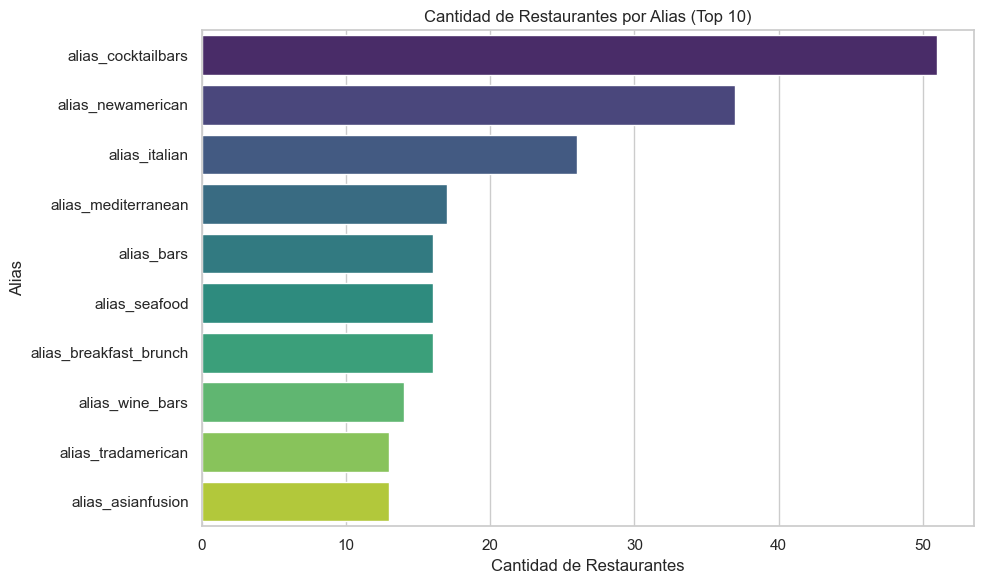

In [28]:
# Seleccionar solo columnas dummies que correspondan a alias (tipos de cocina)
alias_cols = [col for col in rest.columns if col.startswith('alias_')]
alias_counts = rest[alias_cols].sum().sort_values(ascending=False).head(10)
alias_df = alias_counts.reset_index()
alias_df.columns = ['alias','cantidad_restaurantes']
# Llamado compatible con plot_custom para barras horizontales
plot_custom(
    alias_df,
    tipo='bar',
    x='cantidad_restaurantes',
    y='alias',
    palette='viridis',
    title='Cantidad de Restaurantes por Alias (Top 10)',
    xlabel='Cantidad de Restaurantes',
    ylabel='Alias',
    horizontal=True,
    figsize=(10,6)
 )

### Gráfico 16: Gráfico de conteo de preferencias alimenticias

El gráfico de conteo permite visualizar la frecuencia de cada preferencia alimenticia entre los usuarios, identificando tendencias de consumo y oportunidades para campañas segmentadas según hábitos alimentarios.

c:\Users\Usuario\Desktop\HENRY\PI\ProyectoM1_JacquetAlexis\Avances - Notebooks\tools.py:146: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=y, data=df, order=order, palette=palette, hue=hue)


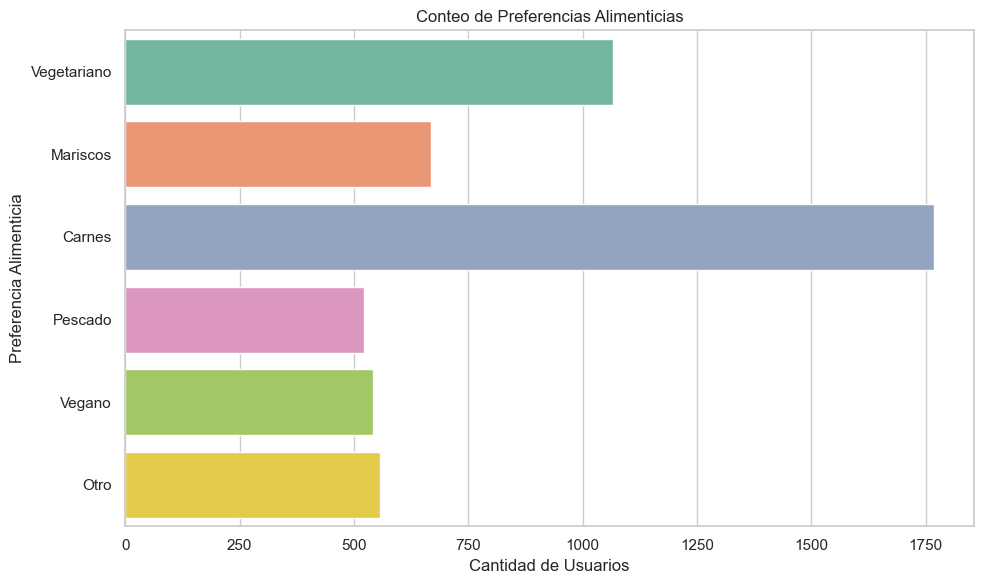

In [29]:
plot_custom(users, tipo='count', y='preferencias_alimenticias', palette='Set2', title='Conteo de Preferencias Alimenticias', xlabel='Cantidad de Usuarios', ylabel='Preferencia Alimenticia', horizontal=True)

## Recomendación Personalizada de Restaurantes

Se implementó la función `recomendar_rest`, que permite sugerir restaurantes personalizados para cada usuario en base a sus características y preferencias. Esta función toma como argumentos el ID del usuario, el DataFrame de restaurantes, el DataFrame de usuarios y la cantidad de recomendaciones deseadas. Devuelve una lista de restaurantes sugeridos para ese usuario, facilitando la personalización de campañas y la mejora de la experiencia del cliente.

**Ejemplo de uso:**
```python
recomendar_rest(9148064715, rest, users, 5)
```
Donde `9148064715` es el ID del usuario, `rest` y `users` son los DataFrames, y `5` es la cantidad de recomendaciones.

A continuación se muestran 10 casos de uso reales con diferentes usuarios:


In [30]:
# Ejecución de 10 casos de uso de la función recomendar_rest con IDs reales
ids_usuarios = users['id_persona'].sample(10, random_state=42).tolist()
for uid in ids_usuarios:
    print(f'Recomendaciones para usuario {uid}:')
    print(recomendar_rest(uid, rest, users, 5))
    print('-'*60)

Recomendaciones para usuario 1862274520:
--- Datos del usuario ---
Nombre: Susan Clarke
Preferencia alimenticia: Carnes
Estrato socioeconómico: Bajo
Gasto promedio comida: 6.51

Restaurantes recomendados:


,Nombre Restaurante,Dirección
0,girl-and-the-goat-chicago,"809 W Randolph, ,"
1,the-purple-pig-chicago,"444 N Michigan Ave,"
2,gretel-chicago,"2833 W Armitage Ave,"
3,cindys-rooftop-chicago,"12 S Michigan Ave, ,"
4,ciccio-mio-chicago-2,"226 W Kinzie,"


None
------------------------------------------------------------
Recomendaciones para usuario 2857228002:
--- Datos del usuario ---
Nombre: Robin Thomas
Preferencia alimenticia: Vegetariano
Estrato socioeconómico: Alto
Gasto promedio comida: 30.41

Restaurantes recomendados:


,Nombre Restaurante,Dirección
0,the-purple-pig-chicago,"444 N Michigan Ave,"
1,aba-chicago-2,"302 N Green St, Fl 3"
2,bigsuda-chicago,"1362 N Milwaukee Ave,"
3,il-porcellino-chicago,"59 W Hubbard St, ,"
4,ema-chicago-6,74 W Illinois St


None
------------------------------------------------------------
Recomendaciones para usuario 1768434922:
--- Datos del usuario ---
Nombre: Shannon Glass
Preferencia alimenticia: Carnes
Estrato socioeconómico: Medio
Gasto promedio comida: 24.52

Restaurantes recomendados:


...

None
------------------------------------------------------------
Recomendaciones para usuario 1921171206:
--- Datos del usuario ---
Nombre: Joshua Jimenez
Preferencia alimenticia: Otro
Estrato socioeconómico: Medio
Gasto promedio comida: 24.24

Restaurantes recomendados:


,Nombre Restaurante,Dirección
0,girl-and-the-goat-chicago,"809 W Randolph, ,"
1,gretel-chicago,"2833 W Armitage Ave,"
2,the-dearborn-chicago-2,"145 N Dearborn St,"
3,penumbra-chicago,"3309 W Fullerton Ave,"
4,no-vacancy-chicago,"509 N Wells St,"


None
------------------------------------------------------------
Recomendaciones para usuario 2655760183:
--- Datos del usuario ---
Nombre: Amanda Flores
Preferencia alimenticia: Vegano
Estrato socioeconómico: Bajo
Gasto promedio comida: 7.5

Restaurantes recomendados:


,Nombre Restaurante,Dirección
0,italian-homemade-company-chicago,"947 W Fulton Market St,"
1,mabu-generation-chicago,"2022 S Archer Ave,"
2,mogadishu-restaurant-chicago-2,"931 N Orleans St, ,"


None
------------------------------------------------------------


## Conclusión Ejecutiva y Recomendaciones

El análisis exhaustivo de los datos de usuarios y restaurantes de Chicago, utilizando variables numéricas, categóricas y especialmente los alias (categorías codificadas como variables dummies), permite identificar patrones claros y oportunidades estratégicas para la empresa:

- **Segmentación efectiva**: Existen grupos etarios y socioeconómicos bien definidos, lo que permite diseñar campañas personalizadas y maximizar el retorno de inversión en marketing.
- **Preferencias alimenticias**: Las tendencias en preferencias alimenticias muestran oportunidades para alianzas con restaurantes de nicho y campañas temáticas.
- **Restaurantes destacados**: Los negocios con altos ratings y muchas reseñas son aliados ideales para promociones y programas de fidelización.
- **Gasto y valor**: Identificar usuarios de alto gasto y su comportamiento permite crear ofertas exclusivas y estrategias de retención.
- **Oferta gastronómica por alias**: El análisis de los alias más frecuentes (a partir de variables dummies) permite identificar la presencia y predominancia de ciertas categorías de restaurantes, facilitando la segmentación de campañas y la identificación de tendencias de oferta en la ciudad.
- **Oportunidades de mejora**: Restaurantes con baja valoración pero alto volumen de clientes pueden beneficiarse de asesoría y campañas de reputación.

**Recomendaciones:**
1. Implementar campañas segmentadas por edad, estrato y preferencias alimenticias.
2. Potenciar alianzas con restaurantes mejor valorados y de mayor engagement.
3. Desarrollar programas de fidelización para usuarios de alto gasto.
4. Aprovechar la información de alias para identificar oportunidades de posicionamiento y colaboraciones estratégicas.
5. Monitorear periódicamente los KPIs visualizados para ajustar la estrategia y anticipar cambios en el mercado.

Este informe proporciona una base sólida para la toma de decisiones orientada a resultados y crecimiento sostenible en el sector gastronómico de Chicago, utilizando la estructura real de los datos disponibles.